# Fabio Arayya Pratama
# 24083010064
# MACHINE LEARNING D

# Install Library Dataset

In [63]:
!pip install kagglehub

In [64]:
import kagglehub

kagglehub.login()

#API: KGAT_86d40582cc900579b837fc8741afab8a

In [65]:
kagglehub.competition_download('walmart-recruiting-store-sales-forecasting')

'/root/.cache/kagglehub/competitions/walmart-recruiting-store-sales-forecasting'

In [66]:
import os

# List the contents of the downloaded competition directory
competition_dir = '/root/.cache/kagglehub/competitions/walmart-recruiting-store-sales-forecasting'
print(os.listdir(competition_dir))


['train.csv.zip', 'stores.csv', 'test.csv', 'sampleSubmission.csv.zip', 'features.csv.zip', 'test.csv.zip', 'train.csv', 'features.csv', 'sampleSubmission.csv']


In [67]:
import pandas as pd
import os
import zipfile

competition_dir = '/root/.cache/kagglehub/competitions/walmart-recruiting-store-sales-forecasting'

# List all files in the directory
all_files = os.listdir(competition_dir)
print(f"Files in competition directory: {all_files}")

datasets = {}

for file_name in all_files:
    file_path = os.path.join(competition_dir, file_name)

    if file_name.endswith('.zip'):
        # Unzip the file
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            # Extract all files into the same directory
            zip_ref.extractall(competition_dir)
            print(f"Extracted {file_name}")
            # Assuming there's only one CSV inside each zip and it has the same name as the zip without .zip
            unzipped_csv_name = file_name.replace('.zip', '')
            unzipped_csv_path = os.path.join(competition_dir, unzipped_csv_name)
            if os.path.exists(unzipped_csv_path):
                try:
                    df_name = unzipped_csv_name.replace('.csv', '')
                    datasets[df_name] = pd.read_csv(unzipped_csv_path)
                    print(f"Loaded {unzipped_csv_name}")
                except Exception as e:
                    print(f"Error loading {unzipped_csv_name}: {e}")

    elif file_name.endswith('.csv'):
        # Load existing CSV files (like stores.csv)
        df_name = file_name.replace('.csv', '')
        if df_name not in datasets: # Avoid reloading stores_df if already loaded
            try:
                datasets[df_name] = pd.read_csv(file_path)
                print(f"Loaded {file_name}")
            except Exception as e:
                print(f"Error loading {file_name}: {e}")


print("\n--- Displaying the first 5 rows of each dataset ---")
for name, df in datasets.items():
    print(f"\nDataset: {name}.csv")
    display(df.head())

Files in competition directory: ['train.csv.zip', 'stores.csv', 'test.csv', 'sampleSubmission.csv.zip', 'features.csv.zip', 'test.csv.zip', 'train.csv', 'features.csv', 'sampleSubmission.csv']
Extracted train.csv.zip
Loaded train.csv
Loaded stores.csv
Loaded test.csv
Extracted sampleSubmission.csv.zip
Loaded sampleSubmission.csv
Extracted features.csv.zip
Loaded features.csv
Extracted test.csv.zip
Loaded test.csv

--- Displaying the first 5 rows of each dataset ---

Dataset: train.csv


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False



Dataset: stores.csv


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875



Dataset: test.csv


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False



Dataset: sampleSubmission.csv


,Id,Weekly_Sales
0,1_1_2012-11-02,0
1,1_1_2012-11-09,0
2,1_1_2012-11-16,0
3,1_1_2012-11-23,0
4,1_1_2012-11-30,0



Dataset: features.csv


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


# 1. Import dataset ke dalam Python menggunakan Pandas. Tampilkan:
	•	5 baris pertama dataset
	•	informasi struktur data
	•	statistik deskriptif

In [68]:
df = datasets['train'].merge(datasets['features'], on=['Store','Date','IsHoliday'], how='left')
df = df.merge(datasets['stores'], on='Store', how='left')

print("\n--- 5 Baris Pertama Dataset Gabungan ---")
display(df.head())

print("\n--- Informasi Struktur Data Gabungan ---")
df.info()

print("\n--- Statistik Deskriptif Data Gabungan ---")
display(df.describe())


--- 5 Baris Pertama Dataset Gabungan ---


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315



--- Informasi Struktur Data Gabungan ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  object 
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), object(2)
memor

,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,136727.915739
std,12.785297,30.492054,22711.183519,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,60980.583328
min,1.000000,1.000000,-4988.940000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2079.650000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,7612.030000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,140167.000000
75%,33.000000,74.000000,20205.852500,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,202505.000000
max,45.000000,99.000000,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000


In [69]:
# Informasi struktur data
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  object 
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB
None


In [70]:
# Statistik deskriptif
display(df.describe())

,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,136727.915739
std,12.785297,30.492054,22711.183519,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,60980.583328
min,1.000000,1.000000,-4988.940000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2079.650000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,7612.030000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,140167.000000
75%,33.000000,74.000000,20205.852500,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,202505.000000
max,45.000000,99.000000,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000


### 2. Dari dataset tersebut, identifikasi:
	•	variabel target yang akan diprediksi
	•	variabel fitur (predictor)
	•	tipe data setiap kolom.


- Variabel Target yang akan Diprediksi: **Weekly_Sales**

Alasan:
Karena tujuan kasus adalah memprediksi penjualan mingguan.

Variabel Fitur:

- Store
- Dept
- Date
- IsHoliday
- (Tambahan dari dataset lain: Temperature, Fuel_Price, CPI, Unemployment)

Tipe Data:

- Store = int
- Dept = int
- Date = object
- Weekly_Sales = float
- IsHoliday = boolean

# 3. Penjelasan Variabel
- Store : merupakan identitas toko (lokasi mempengaruhi penjualan)
- Dept : merupakan jenis produk (pola penjualan berbeda)
- Date : merupakan waktu (kunci time series)
- Weekly_Sales : merupakan total penjualan mingguan

Alasan penting:
Penjualan sangat dipengaruhi oleh lokasi, kategori produk, dan waktu.

# 4. Memeriksa Missing Value pada Setiap Kolom

In [71]:
df.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0
Temperature,0
Fuel_Price,0
MarkDown1,270889
MarkDown2,310322
MarkDown3,284479


Terdapat Missing Value yang terdeteksi dari kolom MarkDown1-5. Tetapi untuk file Train>csv Tidak ada Missing Value yang terdeteksi

# 5. Penanganan Missing Value

Metode-metode yang bisa digunakan untuk menangani Missing Value:
- Mean / median → untuk data statis
- Forward Fill → untuk time series
- Back Fill → untuk time series
- Interpolasi → untuk pola kontinu

In [72]:
# Step 1: Apply backward fill for any remaining NaNs (likely at the start of series)
df.fillna(method='bfill', inplace=True)

# Step 2: As a fallback, fill any truly remaining NaNs in MarkDown columns with 0
# This handles cases where a MarkDown column might have been entirely NaN for a specific group/period
# Or if the first data points were NaN and couldn't be filled by ffill or bfill across all groups.
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
for col in markdown_cols:
    df[col].fillna(0, inplace=True)

print("\n--- Missing Values After Bfill and Filling with 0 ---")
print(df.isnull().sum())

/tmp/ipykernel_6843/936245797.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)
/tmp/ipykernel_6843/936245797.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(0, inplace=True)



--- Missing Values After Bfill and Filling with 0 ---
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64


# Metode dipilih: **Backward Fill** lalu **Fill Remaining with 0**

Backward Fill (bfill):

Cara kerja: Mengisi nilai yang hilang menggunakan nilai berikutnya yang valid dalam kolom atau seri yang sama.

Alasan:
- Data bersifat time series
- Nilai sebelumnya lebih relevan dibanding rata-rata
- Menjaga pola temporal


Fill Remaining with 0 :

Setelah bfill, jika masih ada nilai MarkDown yang tersisa (misalnya, jika seluruh nilai MarkDown dari kombinasi Toko/Departemen hilang, yang tidak mungkin tetapi mungkin terjadi), kita dapat mengisinya dengan 0.

# 6. Cek dan Hapus Data Duplikat

In [73]:
print("Duplikat sebelum:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplikat sesudah:", df.duplicated().sum())

Duplikat sebelum: 0
Duplikat sesudah: 0


Mengaoa Data duplikat perlu dihapus, karena Data duplikat bisa:
- menyebabkan bias model
- mengganggu distribusi data

Cara Menghapus dengan langsung melakukan df.drop

# 7.	Mengubah kolom Date menjadi tipe datetime.

In [74]:
print("Before:", df['Date'].dtype)

df['Date'] = pd.to_datetime(df['Date'])

print("After:", df['Date'].dtype)

Before: object
After: datetime64[ns]


Mengapa harus mengubah kolom date menjadi tipe datetime, agar kita dalam menganalisis penjualan mudah dalam:
- ekstrak fitur waktu
- sorting time series

# 8. Membuat fitur baru dari kolom Date

Fitur baru terdiri dari
- Year
- Month
- Week
- Day_of_Week

Alasannya karena Time series sangat bergantung pada musim (bulan), pola mingguan dan tren tahunan

In [75]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df['Day_of_Week'] = df['Date'].dt.dayofweek

print("--- First 5 rows with new date features ---")
display(df[['Date', 'Year', 'Month', 'Week', 'Day_of_Week']].head())

--- First 5 rows with new date features ---


,Date,Year,Month,Week,Day_of_Week
0,2010-02-05,2010,2,5,4
1,2010-02-12,2010,2,6,4
2,2010-02-19,2010,2,7,4
3,2010-02-26,2010,2,8,4
4,2010-03-05,2010,3,9,4


# 9. Pentingnya Fitur Waktu dalam TimeSeries Forecasting

Fitur waktu dalam TimeSeries penting karena:
- menangkap seasonality
- menangkap trend
- meningkatkan akurasi model

Contoh:
- penjualan naik saat liburan
- akhir pekan berbeda dengan hari kerja

# 10.	Buat lag feature dari variabel Weekly_Sales:

In [76]:
df = df.sort_values(['Store','Dept','Date'])

df['Lag_1'] = df.groupby(['Store','Dept'])['Weekly_Sales'].shift(1)
df['Lag_2'] = df.groupby(['Store','Dept'])['Weekly_Sales'].shift(2)
df['Lag_4'] = df.groupby(['Store','Dept'])['Weekly_Sales'].shift(4)

print("--- First 5 rows with new lag features ---")
display(df[['Date', 'Store', 'Dept', 'Weekly_Sales', 'Lag_1', 'Lag_2', 'Lag_4']].head())

--- First 5 rows with new lag features ---


,Date,Store,Dept,Weekly_Sales,Lag_1,Lag_2,Lag_4
0,2010-02-05,1,1,24924.50,NaN,NaN,NaN
1,2010-02-12,1,1,46039.49,24924.50,NaN,NaN
2,2010-02-19,1,1,41595.55,46039.49,24924.50,NaN
3,2010-02-26,1,1,19403.54,41595.55,46039.49,NaN
4,2010-03-05,1,1,21827.90,19403.54,41595.55,24924.5


# 11.	Jelaskan fungsi lag feature dalam model peramalan.

Karena tanpa lag feature bukan merupakan model time series

Fungsi Lag Feature dalam model peramalan:
- Menangkap pola masa lalu
- Dasar utama dari forecasting
- meningkatkan performa model

# 12.	Buat fitur rolling mean untuk Weekly_Sales selama 4 minggu.

In [77]:
df['Rolling_Mean_4'] = df.groupby(['Store','Dept'])['Weekly_Sales'].transform(lambda x: x.rolling(4, min_periods=1).mean())

print("--- First 5 rows with new rolling mean feature ---")
display(df[['Date', 'Store', 'Dept', 'Weekly_Sales', 'Rolling_Mean_4']].head())

--- First 5 rows with new rolling mean feature ---


,Date,Store,Dept,Weekly_Sales,Rolling_Mean_4
0,2010-02-05,1,1,24924.50,24924.500000
1,2010-02-12,1,1,46039.49,35481.995000
2,2010-02-19,1,1,41595.55,37519.846667
3,2010-02-26,1,1,19403.54,32990.770000
4,2010-03-05,1,1,21827.90,32216.620000


# 13.	Gunakan metode visualisasi untuk mendeteksi outlier pada Weekly_Sales:
- Boxplot
- Histogram

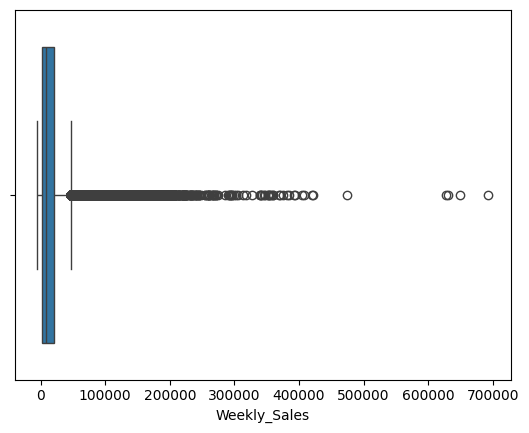

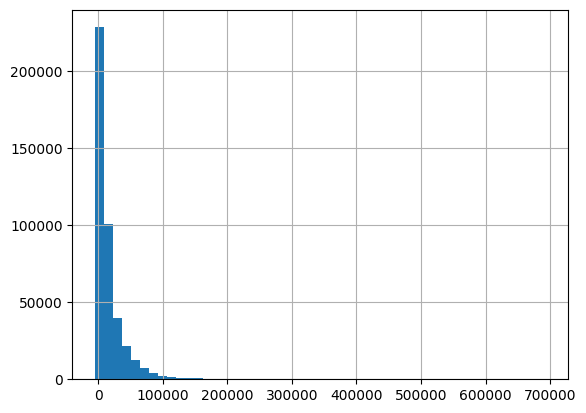

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=df['Weekly_Sales'])
plt.show()

df['Weekly_Sales'].hist(bins=50)
plt.show()

# 14.	Dua metode untuk menangani outlier.

METODE IQR:
- berbasis statistik
- cocok untuk distribusi umum

METODE Capping:
- mempertahankan data
- hanya membatasi nilai ekstrem

# 15. Melakukan normalisasi atau standardisasi pada variabel numerik berikut:
	•	Temperature
	•	Fuel_Price
	•	CPI
	•	Unemployment

In [79]:
from sklearn.preprocessing import StandardScaler

numeric_cols_to_scale = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

# Initialize StandardScaler
scaler = StandardScaler()

# Apply standardization to the selected columns
df[numeric_cols_to_scale] = scaler.fit_transform(df[numeric_cols_to_scale])

print("--- Statistik Deskriptif setelah Standardisasi ---")
display(df[numeric_cols_to_scale].describe())

--- Statistik Deskriptif setelah Standardisasi ---


,Temperature,Fuel_Price,CPI,Unemployment
count,4.215700e+05,4.215700e+05,4.215700e+05,4.215700e+05
mean,1.101622e-15,-1.038248e-17,-5.042920e-16,-1.412557e-15
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,-3.368949e+00,-1.938930e+00,-1.152677e+00,-2.190362e+00
25%,-7.269148e-01,-9.335081e-01,-1.000512e+00,-5.738701e-01
50%,1.084102e-01,1.984094e-01,2.838879e-01,-5.060323e-02
75%,7.691897e-01,8.221635e-01,1.052499e+00,3.282957e-01
max,2.170975e+00,2.414263e+00,1.430847e+00,3.409399e+00


# 16. Jelaskan perbedaan:
Min-Max Scaling dan Standardization

**Min-Max**
- range: 0–1
- cocok untuk neural network

**Standardization**
- mean = 0
- robust terhadap outlier

# 17. Bagi dataset menjadi:
80% data training dan 20% data testing

In [80]:
df = df.sort_values(by='Date').reset_index(drop=True)

split_index = int(len(df) * 0.8)

# Split the dataset
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print(f"Shape of training data: {train_df.shape}")
print(f"Shape of testing data: {test_df.shape}")

print("\n--- First 5 rows of training data ---")
display(train_df.head())

print("\n--- First 5 rows of testing data ---")
display(test_df.head())

Shape of training data: (337256, 24)
Shape of testing data: (84314, 24)

--- First 5 rows of training data ---


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Type,Size,Year,Month,Week,Day_of_Week,Lag_1,Lag_2,Lag_4,Rolling_Mean_4
0,1,1,2010-02-05,24924.50,False,-0.963798,-1.720834,10382.90,6115.67,215.07,...,A,151315,2010,2,5,4,NaN,NaN,NaN,24924.50
1,29,5,2010-02-05,15552.08,False,-1.936808,-1.249747,8394.65,7331.95,200.28,...,B,93638,2010,2,5,4,NaN,NaN,NaN,15552.08
2,29,6,2010-02-05,3200.22,False,-1.936808,-1.249747,8394.65,7331.95,200.28,...,B,93638,2010,2,5,4,NaN,NaN,NaN,3200.22
3,29,7,2010-02-05,10820.05,False,-1.936808,-1.249747,8394.65,7331.95,200.28,...,B,93638,2010,2,5,4,NaN,NaN,NaN,10820.05
4,29,8,2010-02-05,20055.64,False,-1.936808,-1.249747,8394.65,7331.95,200.28,...,B,93638,2010,2,5,4,NaN,NaN,NaN,20055.64



--- First 5 rows of testing data ---


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Type,Size,Year,Month,Week,Day_of_Week,Lag_1,Lag_2,Lag_4,Rolling_Mean_4
337256,26,1,2012-04-13,25890.80,False,-1.257056,1.448099,3766.78,2941.14,24.34,...,A,152513,2012,4,15,4,42803.96,22196.50,17737.41,27067.2075
337257,11,92,2012-04-13,91691.90,False,0.685711,1.155850,8906.38,4722.18,9.86,...,A,207499,2012,4,15,4,88113.75,68451.67,86657.47,80232.3775
337258,23,79,2012-04-13,28446.31,False,-0.990901,1.448099,4460.90,4852.66,25.17,...,B,114533,2012,4,15,4,37141.88,28102.63,31204.65,30774.0425
337259,16,26,2012-04-13,1943.18,False,-0.772991,1.177660,3532.73,1368.42,22.00,...,B,57197,2012,4,15,4,2076.87,2705.01,1823.93,2212.1850
337260,4,12,2012-04-13,7563.94,False,0.466174,1.134041,12506.74,5941.43,30.84,...,A,205863,2012,4,15,4,10344.73,8937.64,9616.27,8688.8300


# 18. Jelaskan mengapa pada time series data tidak boleh dilakukan shuffle sebelum split.

Karena:
- time series bergantung waktu
- shuffle merusak pola
- menyebabkan prediksi tidak valid

# 19.	Visualisasikan tren penjualan mingguan untuk salah satu toko

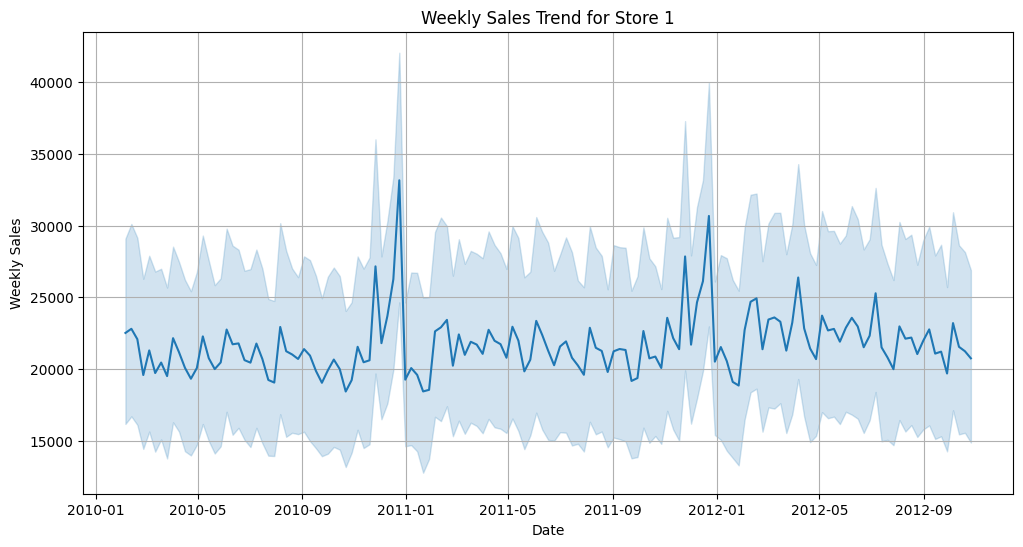

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for a specific store (e.g., Store 1)
store_1 = df[df['Store'] == 1]

plt.figure(figsize=(12, 6))
sns.lineplot(data=store_1, x='Date', y='Weekly_Sales')
plt.title('Weekly Sales Trend for Store 1')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.grid(True)
plt.show()

Berdasarkan visualisasi data penjualan mingguan, karakteristik berikut dapat diidentifikasi:

# **Trend:**
Terdapat kecenderungan penjualan meningkat secara bertahap dari waktu ke waktu, meskipun tidak terlalu dominan karena variasi yang tinggi antar departemen.

# **Seasonality**:
menunjukkan pola musiman yang kuat, ditandai dengan lonjakan penjualan yang berulang selama periode tertentu, terutama menjelang akhir tahun. Ini menunjukkan pengaruh peristiwa tahunan seperti hari libur dan promosi besar.

# **Noise:**
Data mengandung tingkat noise yang tinggi, terlihat dari fluktuasi acak yang signifikan dari waktu ke waktu. Noise ini kemungkinan disebabkan oleh faktor eksternal seperti promosi, kondisi ekonomi, dan karakteristik yang berbeda antar produk.

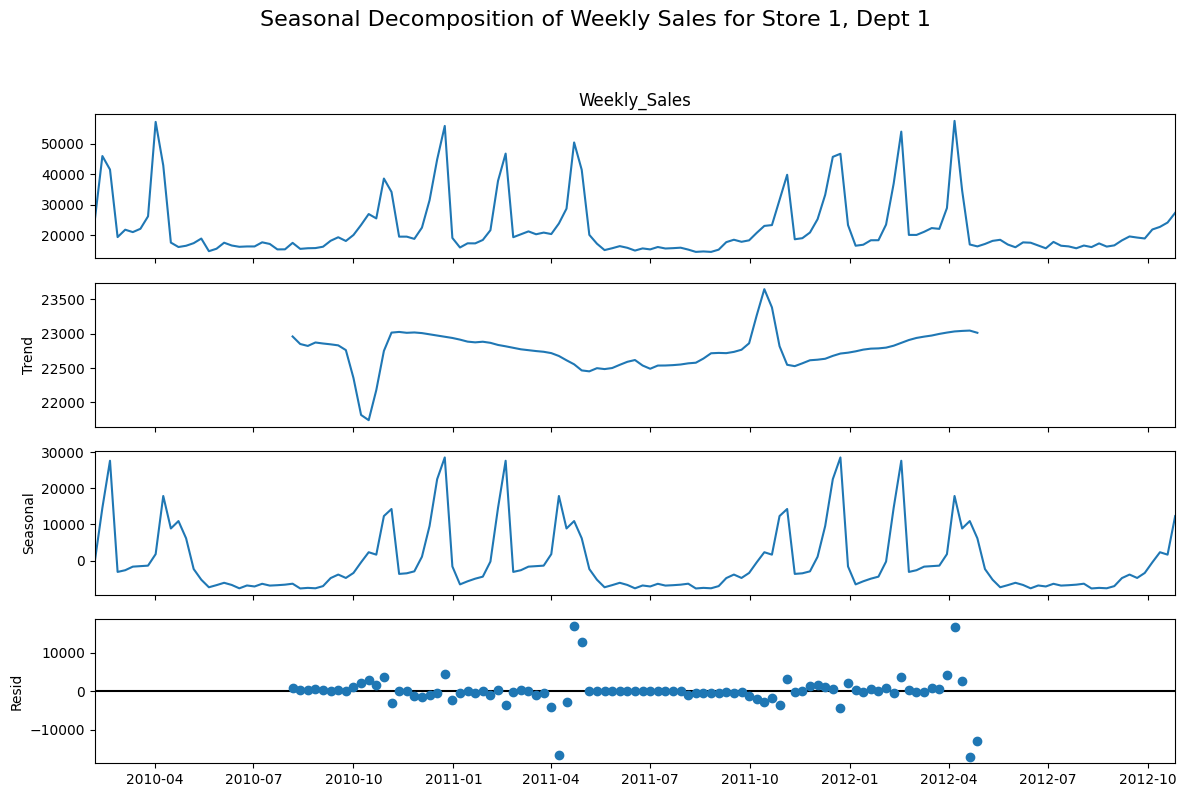

In [82]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import seaborn as sns

store_dept_ts = store_dept.set_index('Date')['Weekly_Sales']

decomposition = seasonal_decompose(store_dept_ts, model='additive', period=52)

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(12, 8)
fig.suptitle('Seasonal Decomposition of Weekly Sales for Store 1, Dept 1', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


# 20.	Identifikasi apakah data memiliki:
- Trend
- Seasonality
- Noise

# Berdasarkan visualisasi data penjualan mingguan, dapat diidentifikasi bahwa data memiliki karakteristik sebagai berikut:

# Trend
Terdapat kecenderungan peningkatan penjualan secara bertahap dari waktu ke waktu, meskipun tidak terlalu dominan karena variasi antar departemen yang cukup tinggi.
# Seasonality
Data menunjukkan pola musiman yang kuat, ditandai dengan lonjakan penjualan yang berulang pada periode tertentu, khususnya menjelang akhir tahun. Hal ini mengindikasikan adanya pengaruh event tahunan seperti hari raya dan promosi besar.
# Noise
Data mengandung tingkat noise yang tinggi, terlihat dari fluktuasi acak yang signifikan di sepanjang waktu. Noise ini kemungkinan disebabkan oleh faktor eksternal seperti promosi, kondisi ekonomi, dan perbedaan karakteristik antar produk.